# Failure Case Analysis

Use the checked-in stress scenarios to identify where the quantum-inspired solver fails and inspect the runtime-vs-latency tradeoff.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
df = pd.concat([
    pd.read_csv('../results/tables/tcp_bursty.csv'),
    pd.read_csv('../results/tables/edge_overload_smoke.csv'),
], ignore_index=True)
df[['scenario_name', 'solver_name', 'time_slot', 'p99_latency_ms', 'goodput_mbps', 'quality_gap']].head()

,scenario_name,solver_name,time_slot,p99_latency_ms,goodput_mbps,quality_gap
0,tcp_bursty,greedy,0,21.743816,129.207602,2.497964
1,tcp_bursty,greedy,1,24.801849,142.689237,7.021538
2,tcp_bursty,greedy,2,23.603198,134.128247,40.796803
3,tcp_bursty,greedy,3,21.383091,176.080127,3.219604
4,tcp_bursty,shortest_path_nearest_edge,0,25.746910,130.401483,0.125729


In [2]:
worst = df.sort_values('p99_latency_ms', ascending=False).head(12)
worst[['scenario_name', 'solver_name', 'time_slot', 'p99_latency_ms', 'goodput_mbps', 'solver_runtime_s', 'quality_gap']]

,scenario_name,solver_name,time_slot,p99_latency_ms,goodput_mbps,solver_runtime_s,quality_gap
26,edge_overload,greedy,2,40.975351,60.301974,0.000190,0.461713
34,edge_overload,quantum_inspired,2,40.975351,60.301974,0.597463,0.461713
35,edge_overload,quantum_inspired,3,37.939961,64.719459,0.545301,0.306016
27,edge_overload,greedy,3,37.939961,64.719459,0.000178,0.306016
33,edge_overload,quantum_inspired,1,35.587813,78.816769,0.552920,0.588447
25,edge_overload,greedy,1,35.587813,78.816769,0.000164,0.588447
7,tcp_bursty,shortest_path_nearest_edge,3,35.175999,176.953730,0.000194,0.621056
32,edge_overload,quantum_inspired,0,33.169119,74.124133,0.521312,0.600387
24,edge_overload,greedy,0,33.169119,74.124133,0.000191,0.600387
6,tcp_bursty,shortest_path_nearest_edge,2,31.936531,133.504056,0.000236,0.634162


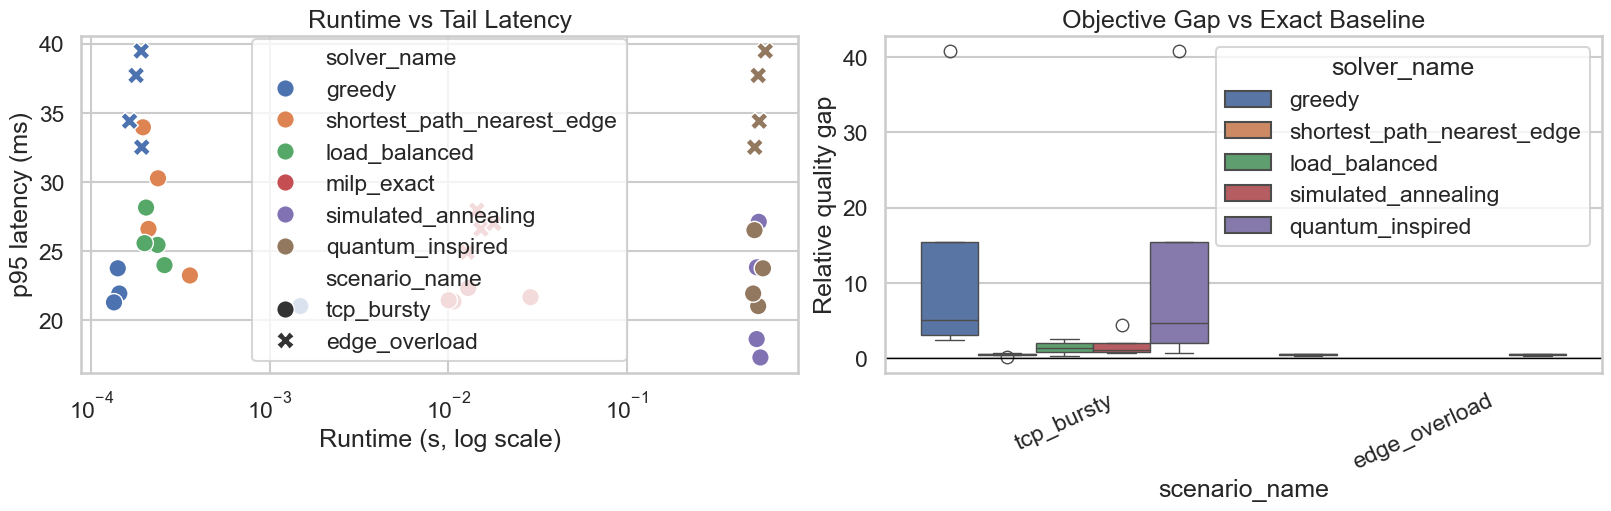

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.scatterplot(data=df, x='solver_runtime_s', y='p95_latency_ms', hue='solver_name', style='scenario_name', s=160, ax=axes[0])
axes[0].set_xscale('log')
axes[0].set_title('Runtime vs Tail Latency')
axes[0].set_xlabel('Runtime (s, log scale)')
axes[0].set_ylabel('p95 latency (ms)')

quality_df = df.dropna(subset=['quality_gap']).copy()
sns.boxplot(data=quality_df, x='scenario_name', y='quality_gap', hue='solver_name', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Objective Gap vs Exact Baseline')
axes[1].set_ylabel('Relative quality gap')
axes[1].tick_params(axis='x', rotation=25)
plt.show()

In [4]:
df.groupby(['scenario_name', 'solver_name'], as_index=False)[['p95_latency_ms', 'goodput_mbps', 'edge_utilization']].mean().sort_values(['scenario_name', 'p95_latency_ms'])

,scenario_name,solver_name,p95_latency_ms,goodput_mbps,edge_utilization
1,edge_overload,milp_exact,26.619538,47.654885,1.0000
0,edge_overload,greedy,36.025526,69.490584,1.0000
2,edge_overload,quantum_inspired,36.025526,69.490584,1.0000
5,tcp_bursty,milp_exact,21.701255,146.376457,1.0000
8,tcp_bursty,simulated_annealing,21.723450,130.051044,0.9875
3,tcp_bursty,greedy,22.001962,145.526303,1.0000
6,tcp_bursty,quantum_inspired,23.307489,142.228763,1.0000
4,tcp_bursty,load_balanced,25.790233,144.839943,1.0000
7,tcp_bursty,shortest_path_nearest_edge,28.518706,146.106244,1.0000
